dependencies

In [30]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as opt

In [31]:
# Data Path initialization

# Determine script directory
base_path = Path.cwd()

# Paths for data and images
data_path = base_path / 'Data' / 'Datasheet.xlsx'
img_path = base_path.parent / 'Images'

# import data from path
Data = pd.read_excel(data_path, sheet_name='Planck', engine='openpyxl')

In [32]:
U366 = np.array([[-x, y] for x, y in zip(Data['U (366nm)'].tolist(), Data['Error U (366nm)'].tolist())])
U366 = U366[~np.isnan(U366).all(axis=1)]
I366 = np.array([[x, y] for x, y in zip(Data['I (366nm)'].tolist(), Data['Error I (366nm)'].tolist())])
I366 = I366[~np.isnan(I366).all(axis=1)]

U436 = np.array([[-x,y] for x,y in zip(Data['U (436nm)'].tolist(), Data['Error U (436nm)'].tolist())])  
U436 = U436[~np.isnan(U436).all(axis=1)]
I436 = np.array([[x, y] for x, y in zip(Data['I (436nm)'].tolist(), Data['Error I (436nm)'].tolist())])
I436 = I436[~np.isnan(I436).all(axis=1)]

U546 = np.array([[-x, y] for x, y in zip(Data['U (546nm)'].tolist(), Data['Error U (546nm)'].tolist())])
U546 = U546[~np.isnan(U546).all(axis=1)]
I546 = np.array([[x, y] for x, y in zip(Data['I (546nm)'].tolist(), Data['Error I (546nm)'].tolist())])
I546 = I546[~np.isnan(I546).all(axis=1)]

U578 = np.array([[-x, y] for x, y in zip(Data['U (578nm)'].tolist(), Data['Error U (578nm)'].tolist())])
U578 = U578[~np.isnan(U578).all(axis=1)]
I578 = np.array([[x,y] for x,y in zip(Data['I (578nm)'].tolist(), Data['Error I (578nm)'].tolist())])
I578 = I578[~np.isnan(I578).all(axis=1)]

U405 = np.array([[-x, y] for x, y in zip(Data['U (405nm)'].tolist(), Data['Error U (405nm)'].tolist())])
U405 = U405[~np.isnan(U405).all(axis=1)]
I405 = np.array([[x,y] for x,y in zip(Data['I (405nm)'].tolist(), Data['Error I (405nm)'].tolist())])
I405 = I405[~np.isnan(I405).all(axis=1)]

In [33]:
def lin(x, a, b):
    return a*x+b

e = 1.602176634 * 10**(-19)  # elementary charge in C

# 366 nm

Fit parameters for 366nm (horizontal): a = 0.04063710180146566 ± 0.025066488136097825, b = -1.1825880404216842 ± 0.07647765533730076
Fit parameters for 366nm (vertical): a = 8.073368522944556 ± 0.1639838933685204, b = 6.463319163408136 ± 0.05409247585949524


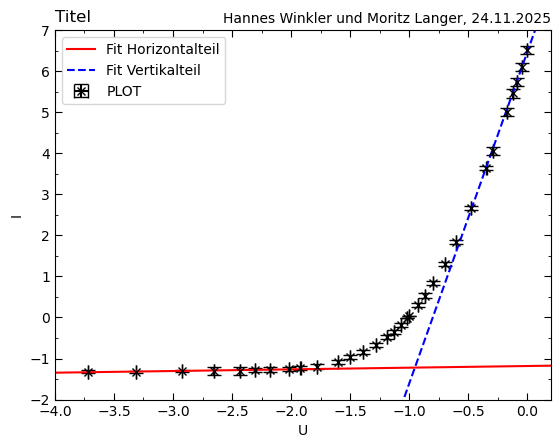

In [34]:
# set fit range

maskH = U366[:, 0] <= -2
U366H = U366[maskH]
I366H = I366[maskH]

maskV = U366[:, 0] >= -0.5
U366V = U366[maskV]
I366V = I366[maskV]

fit_range = np.linspace(-5, 5, 100)

# Fitting
params366H, cov366H = opt.curve_fit(lin, [x[0] for x in U366H], [x[0] for x in I366H], sigma=[x[1] for x in I366H], absolute_sigma=True)
errors366H = np.sqrt(np.diag(cov366H))
print(f'Fit parameters for 366nm (horizontal): a = {params366H[0]} ± {errors366H[0]}, b = {params366H[1]} ± {errors366H[1]}')

params366V, cov366V = opt.curve_fit(lin, [x[0] for x in U366V], [x[0] for x in I366V], sigma=[x[1] for x in I366V], absolute_sigma=True)
errors366V = np.sqrt(np.diag(cov366V))
print(f'Fit parameters for 366nm (vertical): a = {params366V[0]} ± {errors366V[0]}, b = {params366V[1]} ± {errors366V[1]}')

# plotting
plt.errorbar([x[0] for x in U366], [x[0] for x in I366],xerr=[x[1] for x in U366], yerr=[x[1] for x in I366], capsize=5, label='PLOT', color='black', marker='x', linestyle='None') # plot with error bars
plt.plot(fit_range, lin(fit_range, params366H[0], params366H[1]), label='Fit Horizontalteil', color='red') # plot fit line
plt.plot(fit_range, lin(fit_range, params366V[0], params366V[1]), label='Fit Vertikalteil', color='blue', linestyle='--') # plot fit line

plt.xlabel('U')
plt.ylabel('I')
plt.title('Titel', loc='left')
plt.text(1, 1.05, 'Hannes Winkler und Moritz Langer, 24.11.2025', ha='right', va='top', transform=plt.gca().transAxes, fontsize=10)
plt.legend()

# locating and arranging ticks
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.xticks(np.arange(800000, 3000100, 200000))
# plt.yticks(np.arange(8, 30, 1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

# limiting and setting plot layout
plt.ylim(-2, 7)
plt.xlim(-4, 0.2)
# plt.tight_layout()

# plot location
plt.savefig(img_path / 'Planck366.png')
plt.show() # shows plot every run of the code, used for debugging

# 405 nm

Fit parameters for 405nm (horizontal): a = 0.007932938898082678 ± 0.0038742877769695587, b = -0.42110244557385645 ± 0.00819560227755098
Fit parameters for 405nm (vertical): a = 2.580430622229818 ± 0.021926292789551525, b = 1.596103082197862 ± 0.007960666908324704


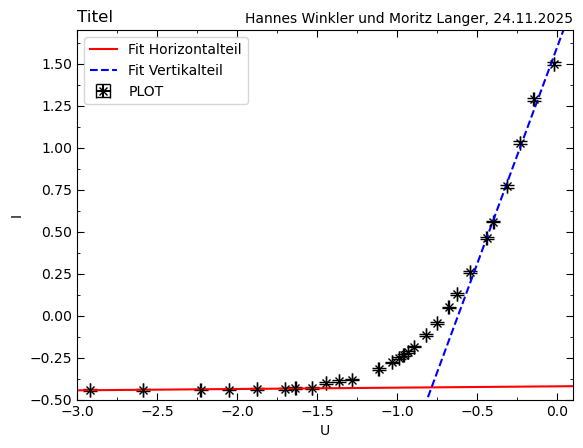

In [35]:
# set fit range

maskH = U405[:, 0] <= -1.48
U405H = U405[maskH]
I405H = I405[maskH]

maskV = U405[:, 0] >= -0.5
U405V = U405[maskV]
I405V = I405[maskV]

fit_range = np.linspace(-5, 5, 100)

# Fitting
params405H, cov405H = opt.curve_fit(lin, [x[0] for x in U405H], [x[0] for x in I405H], sigma=[x[1] for x in I405H], absolute_sigma=True)
errors405H = np.sqrt(np.diag(cov405H))
print(f'Fit parameters for 405nm (horizontal): a = {params405H[0]} ± {errors405H[0]}, b = {params405H[1]} ± {errors405H[1]}')

params405V, cov405V = opt.curve_fit(lin, [x[0] for x in U405V], [x[0] for x in I405V], sigma=[x[1] for x in I405V], absolute_sigma=True)
errors405V = np.sqrt(np.diag(cov405V))
print(f'Fit parameters for 405nm (vertical): a = {params405V[0]} ± {errors405V[0]}, b = {params405V[1]} ± {errors405V[1]}')

# plotting
plt.errorbar([x[0] for x in U405], [x[0] for x in I405],xerr=[x[1] for x in U405], yerr=[x[1] for x in I405], capsize=5, label='PLOT', color='black', marker='x', linestyle='None') # plot with error bars
plt.plot(fit_range, lin(fit_range, params405H[0], params405H[1]), label='Fit Horizontalteil', color='red') # plot fit line
plt.plot(fit_range, lin(fit_range, params405V[0], params405V[1]), label='Fit Vertikalteil', color='blue', linestyle='--') # plot fit line

plt.xlabel('U')
plt.ylabel('I')
plt.title('Titel', loc='left')
plt.text(1, 1.05, 'Hannes Winkler und Moritz Langer, 24.11.2025', ha='right', va='top', transform=plt.gca().transAxes, fontsize=10)
plt.legend()

# locating and arranging ticks
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.xticks(np.arange(800000, 3000100, 200000))
# plt.yticks(np.arange(8, 30, 1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

# limiting and setting plot layout
plt.ylim(-0.5, 1.7)
plt.xlim(-3, 0.1)
# plt.tight_layout()

# plot location
plt.savefig(img_path / 'Planck405.png')
plt.show() # shows plot every run of the code, used for debugging

# 436 nm

Fit parameters for 436nm (horizontal): a = 0.005099573967090495 ± 0.004923562157203295, b = -0.2025863303912707 ± 0.01123620508656227
Fit parameters for 436nm (vertical): a = 2.192332307784294 ± 0.029725456445764128, b = 1.0381052517493479 ± 0.004811552568432781


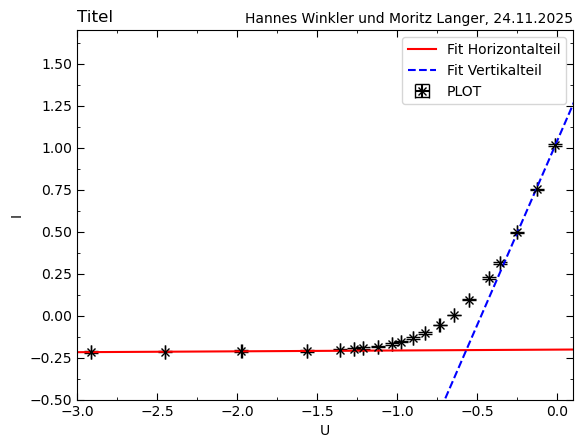

In [36]:
# set fit range

maskH = U436[:, 0] <= -1.48
U436H = U436[maskH]
I436H = I436[maskH]

maskV = U436[:, 0] >= -0.35
U436V = U436[maskV]
I436V = I436[maskV]

fit_range = np.linspace(-5, 5, 100)

# Fitting
params436H, cov436H = opt.curve_fit(lin, [x[0] for x in U436H], [x[0] for x in I436H], sigma=[x[1] for x in I436H], absolute_sigma=True)
errors436H = np.sqrt(np.diag(cov436H))
print(f'Fit parameters for 436nm (horizontal): a = {params436H[0]} ± {errors436H[0]}, b = {params436H[1]} ± {errors436H[1]}')

params436V, cov436V = opt.curve_fit(lin, [x[0] for x in U436V], [x[0] for x in I436V], sigma=[x[1] for x in I436V], absolute_sigma=True)
errors436V = np.sqrt(np.diag(cov436V))
print(f'Fit parameters for 436nm (vertical): a = {params436V[0]} ± {errors436V[0]}, b = {params436V[1]} ± {errors436V[1]}')

# plotting
plt.errorbar([x[0] for x in U436], [x[0] for x in I436],xerr=[x[1] for x in U436], yerr=[x[1] for x in I436 ], capsize=5, label='PLOT', color='black', marker='x', linestyle='None') # plot with error bars
plt.plot(fit_range, lin(fit_range, params436H[0], params436H[1]), label='Fit Horizontalteil', color='red') # plot fit line
plt.plot(fit_range, lin(fit_range, params436V[0], params436V[1]), label='Fit Vertikalteil', color='blue', linestyle='--') # plot fit line

plt.xlabel('U')
plt.ylabel('I')
plt.title('Titel', loc='left')
plt.text(1, 1.05, 'Hannes Winkler und Moritz Langer, 24.11.2025', ha='right', va='top', transform=plt.gca().transAxes, fontsize=10)
plt.legend()

# locating and arranging ticks
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.xticks(np.arange(800000, 3000100, 200000))
# plt.yticks(np.arange(8, 30, 1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

# limiting and setting plot layout
plt.ylim(-0.5, 1.7)
plt.xlim(-3, 0.1)
# plt.tight_layout()

# plot location
plt.savefig(img_path / 'Planck436.png')
plt.show() # shows plot every run of the code, used for debugging

# 546 nm

Fit parameters for 546nm (horizontal): a = 0.011219721809828172 ± 0.003390972488563454, b = -0.23795767946732266 ± 0.00674989192507581
Fit parameters for 546nm (vertical): a = 2.785831572395648 ± 0.0329373723556619, b = 0.8380133132726905 ± 0.004997763685349309


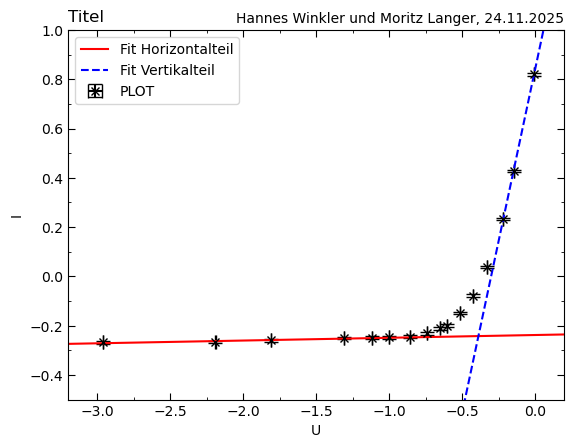

In [44]:
# set fit range

maskH = U546[:, 0] <= -1
U546H = U546[maskH]
I546H = I546[maskH]

maskV = U546[:, 0] >= -0.25
U546V = U546[maskV]
I546V = I546[maskV]

fit_range = np.linspace(-5, 5, 100)

# Fitting
params546H, cov546H = opt.curve_fit(lin, [x[0] for x in U546H], [x[0] for x in I546H], sigma=[x[1] for x in I546H], absolute_sigma=True)
errors546H = np.sqrt(np.diag(cov546H))
print(f'Fit parameters for 546nm (horizontal): a = {params546H[0]} ± {errors546H[0]}, b = {params546H[1]} ± {errors546H[1]}')

params546V, cov546V = opt.curve_fit(lin, [x[0] for x in U546V], [x[0] for x in I546V], sigma=[x[1] for x in I546V], absolute_sigma=True)
errors546V = np.sqrt(np.diag(cov546V))
print(f'Fit parameters for 546nm (vertical): a = {params546V[0]} ± {errors546V[0]}, b = {params546V[1]} ± {errors546V[1]}')

# plotting
plt.errorbar([x[0] for x in U546], [x[0] for x in I546],xerr=[x[1] for x in U546], yerr=[x[1] for x in I546 ], capsize=5, label='PLOT', color='black', marker='x', linestyle='None') # plot with error bars
plt.plot(fit_range, lin(fit_range, params546H[0], params546H[1]), label='Fit Horizontalteil', color='red') # plot fit line
plt.plot(fit_range, lin(fit_range, params546V[0], params546V[1]), label='Fit Vertikalteil', color='blue', linestyle='--') # plot fit line

plt.xlabel('U')
plt.ylabel('I')
plt.title('Titel', loc='left')
plt.text(1, 1.05, 'Hannes Winkler und Moritz Langer, 24.11.2025', ha='right', va='top', transform=plt.gca().transAxes, fontsize=10)
plt.legend()

# locating and arranging ticks
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.xticks(np.arange(800000, 3000100, 200000))
# plt.yticks(np.arange(8, 30, 1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

# limiting and setting plot layout
plt.ylim(-0.5, 1)
plt.xlim(-3.2, 0.2)
# plt.tight_layout()

# plot location
plt.savefig(img_path / 'Planck546.png')
plt.show() # shows plot every run of the code, used for debugging

# 578 nm

Fit parameters for 578nm (horizontal): a = 0.001900287287849292 ± 0.002719449541101149, b = -0.05458185802721527 ± 0.005324160134601157
Fit parameters for 578nm (vertical): a = 0.5511542720845047 ± 0.0602356908197252, b = 0.1154353778004941 ± 0.004229989884757232


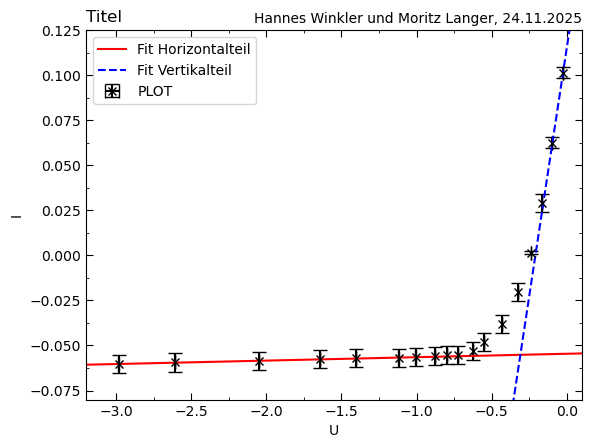

In [60]:
# set fit range

maskH = U578[:, 0] <= -1
U578H = U578[maskH]
I578H = I578[maskH]

maskV = U578[:, 0] >= -0.15
U578V = U578[maskV]
I578V = I578[maskV]

fit_range = np.linspace(-5, 5, 100)

# Fitting
params578H, cov578H = opt.curve_fit(lin, [x[0] for x in U578H], [x[0] for x in I578H], sigma=[x[1] for x in I578H], absolute_sigma=True)
errors578H = np.sqrt(np.diag(cov578H))
print(f'Fit parameters for 578nm (horizontal): a = {params578H[0]} ± {errors578H[0]}, b = {params578H[1]} ± {errors578H[1]}')

params578V, cov578V = opt.curve_fit(lin, [x[0] for x in U578V], [x[0] for x in I578V], sigma=[x[1] for x in I578V], absolute_sigma=True)
errors578V = np.sqrt(np.diag(cov578V))
print(f'Fit parameters for 578nm (vertical): a = {params578V[0]} ± {errors578V[0]}, b = {params578V[1]} ± {errors578V[1]}')

# plotting
plt.errorbar([x[0] for x in U578], [x[0] for x in I578],xerr=[x[1] for x in U578], yerr=[x[1] for x in I578 ], capsize=5, label='PLOT', color='black', marker='x', linestyle='None') # plot with error bars
plt.plot(fit_range, lin(fit_range, params578H[0], params578H[1]), label='Fit Horizontalteil', color='red') # plot fit line
plt.plot(fit_range, lin(fit_range, params578V[0], params578V[1]), label='Fit Vertikalteil', color='blue', linestyle='--') # plot fit line

plt.xlabel('U')
plt.ylabel('I')
plt.title('Titel', loc='left')
plt.text(1, 1.05, 'Hannes Winkler und Moritz Langer, 24.11.2025', ha='right', va='top', transform=plt.gca().transAxes, fontsize=10)
plt.legend()

# locating and arranging ticks
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
# plt.xticks(np.arange(800000, 3000100, 200000))
# plt.yticks(np.arange(8, 30, 1))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)

# limiting and setting plot layout
plt.ylim(-0.08, 0.125)
plt.xlim(-3.2, 0.1)
# plt.tight_layout()

# plot location
plt.savefig(img_path / 'Planck578.png')
plt.show() # shows plot every run of the code, used for debugging